# Pattern #2: Tool Use — Bridge to the Outside World

**LangGraph Implementation**

## Overview

Tools enable agents to interact with the external world. We build **two separate graphs** and compare them:

**Baseline Graph** (no tools):
```
START → generate → END
```

**Tool-Enhanced Graph** (with web_search):
```
START → search → generate → END
```

LangGraph makes the tool integration explicit — the `search` node is a visible step in the graph.

**Architecture reminder:**
- **Internal Memory**: RAG retrieval (agent cognition — not a tool)
- **External Action**: web_search (agent tool — visible in the graph)

In [17]:
import sys
import time
sys.path.append('..')

from langgraph.graph import StateGraph, START, END
from typing import TypedDict
from IPython.display import Image, display

from utils import create_llm_provider, get_config
from tools import get_web_search_tool


def show_graph(runnable):
    """Render the LangGraph graph as a Mermaid diagram."""
    try:
        display(Image(runnable.get_graph().draw_mermaid_png()))
    except Exception:
        print(runnable.get_graph().draw_mermaid())


config = get_config()
llm = create_llm_provider()
web_search = get_web_search_tool()

print(f"Using model: {config.get('model')}")
print(f"Web search provider: Tavily")
print(f"Timezone: {config.get('output.timezone')}")

Using model: openai/gpt-4o-mini
Web search provider: Tavily
Timezone: Asia/Colombo


## Project Structure

All notebooks in this repo share a set of utility modules in the parent directory:

| Module | Purpose |
|---|---|
| `utils/` | LLM provider factory (`create_llm_provider`), config loader (`get_config`), token counter |
| `rag_internal/` | Internal RAG retriever backed by Qdrant — represents *agent memory*, not a tool |
| `tools/` | External tools: `web_search` (Tavily) and `booking_tool` (local JSON lookup) |
| `config/` | `models.yaml` and `params.yaml` — provider, model, and RAG settings |
| `data/` | Medical knowledge `.txt` files for RAG and `bookings.json` for the booking tool |

This notebook uses `utils/` and `tools/web_search` — the Tool Use pattern is about agents interacting with the external world.

### Validation

In [18]:
assert config.get("model"), "config.get('model') should be set"
assert llm is not None and callable(getattr(web_search, "search", None)), "LLM and web_search ready"
print("\u2713 Setup valid: config, LLM, and web_search ready.")

✓ Setup valid: config, LLM, and web_search ready.


## State Definitions

We define two state types — one for each graph.

| Field | Baseline | Tool-Enhanced | Purpose |
|---|---|---|---|
| `query` | ✓ | ✓ | User question |
| `response` | ✓ | ✓ | LLM output |
| `tokens` | ✓ | ✓ | Token usage |
| `llm_latency_ms` | ✓ | ✓ | LLM generation time |
| `search_latency_ms` | — | ✓ | Web search time (separate from LLM) |
| `search_results` | — | ✓ | Web search context |
| `sources` | — | ✓ | Source URLs |

Tracking `search_latency_ms` separately makes the "Latency increase" comparison accurate — search time was previously excluded from the measurement.

In [19]:
class BaselineState(TypedDict):
    query: str
    response: str
    tokens: int
    llm_latency_ms: int


class ToolEnhancedState(TypedDict):
    query: str
    search_results: str
    search_latency_ms: int
    sources: list
    response: str
    tokens: int
    llm_latency_ms: int

## Graph 1: Baseline (No Tools)

```
START → generate → END
```

The LLM answers from training data alone — no external information.

Baseline graph compiled ✓


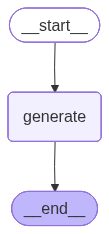

In [20]:
def baseline_generate(state: BaselineState) -> dict:
    """Generate response without any tools."""
    start = time.time()
    response = llm.generate(
        prompt=state["query"],
        system_prompt=(
            "You are a healthcare assistant for Sri Lankan hospitals. "
            "Provide helpful information about hospital services. "
            'Always end with: "This is educational information; verify with the hospital / consult your clinician."'
        ),
    )
    return {
        "response": response["response"],
        "tokens": response["total_tokens"],
        "llm_latency_ms": int((time.time() - start) * 1000),
    }


baseline_graph = StateGraph(BaselineState)
baseline_graph.add_node("generate", baseline_generate)
baseline_graph.add_edge(START, "generate")
baseline_graph.add_edge("generate", END)

baseline_app = baseline_graph.compile()
print("Baseline graph compiled \u2713")

show_graph(baseline_app)

## Graph 2: Tool-Enhanced (With web_search)

```
START → search → generate → END
```

The `search` node fetches real-time information, which the `generate` node uses as context.

Tool-enhanced graph compiled ✓


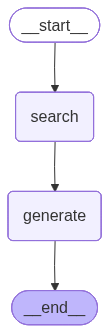

In [21]:
def search_node(state: ToolEnhancedState) -> dict:
    """Perform web search and store results + search latency in state."""
    search_start = time.time()
    search_result = web_search.search(state["query"])
    search_latency_ms = int((time.time() - search_start) * 1000)
    formatted = web_search.format_results(search_result)
    sources = [r["url"] for r in search_result.get("results", [])]
    return {
        "search_results": formatted,
        "search_latency_ms": search_latency_ms,
        "sources": sources,
    }


def tool_generate(state: ToolEnhancedState) -> dict:
    """Generate response using search results as context."""
    start = time.time()
    response = llm.generate(
        prompt=(
            f"User Question: {state['query']}\n\n"
            f"Web Search Results:\n{state['search_results']}\n\n"
            f"Please provide a comprehensive answer using the search results. Include URLs for verification."
        ),
        system_prompt=(
            "You are a healthcare assistant with access to current web information. "
            "Use the web search results to provide accurate, up-to-date operational information. "
            "Always cite sources and include the checked timestamp. "
            'Always end with: "This is educational information; verify with the hospital / consult your clinician."'
        ),
    )
    return {
        "response": response["response"],
        "tokens": response["total_tokens"],
        "llm_latency_ms": int((time.time() - start) * 1000),
    }


tool_graph = StateGraph(ToolEnhancedState)
tool_graph.add_node("search", search_node)
tool_graph.add_node("generate", tool_generate)

tool_graph.add_edge(START, "search")
tool_graph.add_edge("search", "generate")
tool_graph.add_edge("generate", END)

tool_app = tool_graph.compile()
print("Tool-enhanced graph compiled \u2713")

show_graph(tool_app)

## Comparison Helper

Run both graphs on the same query and compare results side-by-side.

In [22]:
def compare_approaches(query: str):
    """Run both graphs and compare results."""
    print("=" * 80)
    print("BASELINE (No Tools)")
    print("=" * 80)

    baseline_result = baseline_app.invoke({
        "query": query, "response": "", "tokens": 0, "llm_latency_ms": 0,
    })
    print(f"\n{baseline_result['response']}\n")
    print(f"[Tokens: {baseline_result['tokens']}, LLM Latency: {baseline_result['llm_latency_ms']}ms]")
    print("Sources: None\n")

    print("=" * 80)
    print("TOOL-ENHANCED (With web_search)")
    print("=" * 80)

    tool_result = tool_app.invoke({
        "query": query, "search_results": "", "search_latency_ms": 0,
        "sources": [], "response": "", "tokens": 0, "llm_latency_ms": 0,
    })
    total_latency = tool_result["search_latency_ms"] + tool_result["llm_latency_ms"]
    print(f"\n{tool_result['response']}\n")
    print(f"[Tokens: {tool_result['tokens']}, Search: {tool_result['search_latency_ms']}ms, LLM: {tool_result['llm_latency_ms']}ms, Total: {total_latency}ms]")
    print(f"Sources ({len(tool_result['sources'])}):\n")
    for url in tool_result["sources"][:3]:
        print(f"  - {url}")

    print(f"\n{'=' * 80}")
    print("COMPARISON")
    print(f"{'=' * 80}")
    baseline_total = baseline_result["llm_latency_ms"]
    tool_total = tool_result["search_latency_ms"] + tool_result["llm_latency_ms"]
    print(f"Latency increase:      {tool_total - baseline_total}ms  (search: {tool_result['search_latency_ms']}ms + LLM: {tool_result['llm_latency_ms']}ms)")
    print(f"Token increase:        {tool_result['tokens'] - baseline_result['tokens']}")
    print(f"Source verification:   {'Yes (URLs provided)' if tool_result['sources'] else 'No'}")

    return {"baseline": baseline_result, "enhanced": tool_result}

## Example 1: Hospital Hours Query

In [23]:
result1 = compare_approaches("What are the OPD hours for Nawaloka Hospital Colombo?")

BASELINE (No Tools)

Nawaloka Hospital in Colombo typically operates its Outpatient Department (OPD) from Monday to Saturday, with hours generally starting around 8:00 AM and closing around 5:00 PM. However, these hours can vary based on specific departments or services, and it’s advisable to check directly with the hospital for the most accurate and current information.

This is educational information; verify with the hospital / consult your clinician.

[Tokens: 145, LLM Latency: 3793ms]
Sources: None

TOOL-ENHANCED (With web_search)

The Outpatient Department (OPD) hours for Nawaloka Hospital in Colombo are as follows:

- **Nawaloka Hospital OPD**: Open daily from **7:00 AM to 7:00 PM**.
- **Nawaloka Premier Center OPD**: 
  - Monday to Saturday: **7:00 AM to 7:00 PM**
  - Sunday: **7:00 AM to 5:00 PM**

For specific inquiries or to confirm details, you can contact them at **076 624 9933**.

For more information, you can visit their official website: [Nawaloka Hospital](http://nawal

## Example 2: Emergency Contact

In [24]:
result2 = compare_approaches("What is the emergency hotline for Asiri Hospital?")

BASELINE (No Tools)

The emergency hotline for Asiri Hospital in Sri Lanka is typically 011 2 300 300. This number can be used for urgent medical assistance or inquiries regarding emergency services. It's always a good idea to verify the number directly with the hospital or check their official website for the most current information.

This is educational information; verify with the hospital / consult your clinician.

[Tokens: 131, LLM Latency: 1952ms]
Sources: None

TOOL-ENHANCED (With web_search)

The emergency hotline for Asiri Hospital is **1313**, and it operates 24/7 for urgent medical assistance. This hotline is available for anyone needing immediate help or guidance in emergencies.

For more information, you can visit the official Asiri Health website: [Asiri Health](https://asirihealth.com/central-home) or check their contact details at [Asiri Hospital Contacts](https://asirihealth.com/ongoing-number).

This is educational information; verify with the hospital / consult your

## Pattern Summary

### LangGraph vs From-Scratch

| Aspect | From-Scratch | LangGraph |
|---|---|---|
| Tool integration | Manual: call search, pass to LLM | Explicit `search` node in graph |
| Flow visibility | Hidden inside function calls | Graph structure shows the pipeline |
| State management | Return dicts manually | Typed state with automatic merging |
| Extensibility | Modify function internals | Add/remove nodes from graph |

### Key Insights

- **Baseline**: LLM generates from training data (may be outdated/generic)
- **Tool-Enhanced**: Real-time, verified information with sources
- **Graph structure** makes the tool pipeline explicit and modifiable

### When to use web_search:
- Operational information (hours, contacts, addresses)
- Current announcements or changes
- Verification of time-sensitive facts
- Location-specific details

### Architecture

```
Internal Cognition: RAG retrieval (memory — not in graph)
External Action:    web_search (tool — visible as graph node)
```